In [34]:
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # type: ignore
from sklearn.preprocessing import Normalizer
sys.path.append(os.path.abspath("../../"))
from utility.preprocess import tokenizer
from utility.lexicon import LexiconTransformer
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

import json
import pandas as pd
import pickle



In [35]:
with open("../../dataset/train_sentiment.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [36]:
text = df['text']
sentiment = df['sentiment']

# text = df["text"].apply(clean_text)

In [37]:
text_train, text_test, sentiment_train, sentiment_test = train_test_split(
    text, sentiment, test_size=0.2, random_state=42
)

In [38]:
base_models = [
    ("svm", LinearSVC(class_weight="balanced", random_state=42)),
    ("nb", MultinomialNB()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("sgd", SGDClassifier(loss="log_loss", class_weight="balanced", random_state=42)),
    
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [40]:
word_vectorizer = TfidfVectorizer(
    tokenizer=tokenizer,
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_df=0.9,
    min_df=1
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb', 
    ngram_range=(1, 3), 
    sublinear_tf=True,
    max_df=0.9,
    min_df=3
)

combined_features = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer),
    ("lexicon", LexiconTransformer())
], transformer_weights={
    "word_tfidf": 1.0,
    "char_tfidf": 0.5,
    "lexicon": 1.0
})

In [41]:
pipeline = Pipeline([
    ('features', combined_features),
    ('norm', Normalizer()),
    ('classifier', stack_model)
])

pipeline.fit(text_train, sentiment_train)
# stack_model.fit(text_train_tfidf, sentiment_train)

c:\Users\Jin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(max_df=0.9,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 sublinear_tf=True,
                                                                 tokenizer=<function tokenizer at 0x0000019692A6DDA0>)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_df=0.9,
                                                                 min_df=3,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 sublinear_tf=True)),
                                                ('lexicon',
                                                 LexiconTransformer())],
                              transformer_weights={...
                ('classifier',
                 StackingClassifier(cv=5,
                                    estimators=[('svm',
                                                 LinearSVC(class_weight='balanced',
                                                           random_state=42)),
                                                ('nb', MultinomialNB()),
                                                ('lr',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=1000,
                                                                    random_state=42)),
                                                ('sgd',
                                                 SGDClassifier(class_weight='balanced',
                                                               loss='log_loss',
                                                               random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42)))])

In [42]:
y_pred = pipeline.predict(text_test)

print("Accuracy:", accuracy_score(sentiment_test, y_pred))
print(classification_report(sentiment_test, y_pred))
# print(confusion_matrix(sentiment_test, y_pred))

Accuracy: 0.8094444444444444
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86       611
     neutral       0.78      0.72      0.75       617
    positive       0.80      0.85      0.82       572

    accuracy                           0.81      1800
   macro avg       0.81      0.81      0.81      1800
weighted avg       0.81      0.81      0.81      1800



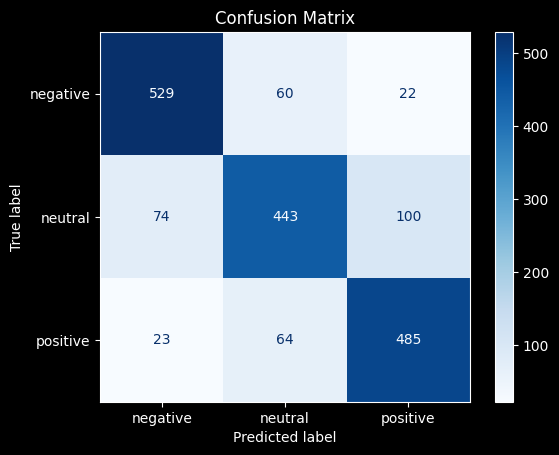

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    sentiment_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

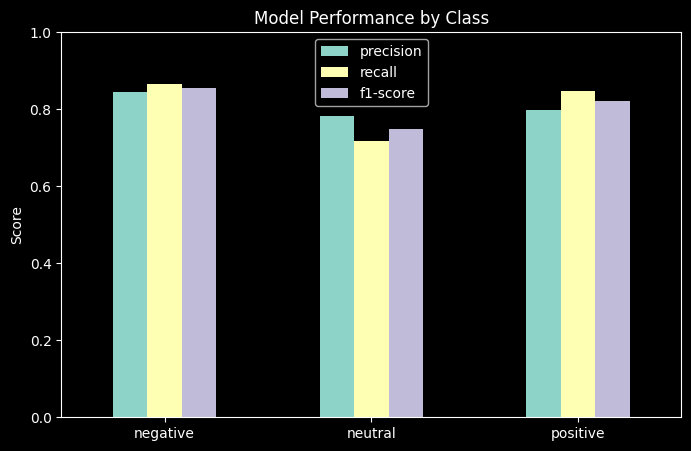

In [44]:
report = classification_report(sentiment_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

df = df.iloc[:3]  # remove accuracy rows

df[["precision","recall","f1-score"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance by Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

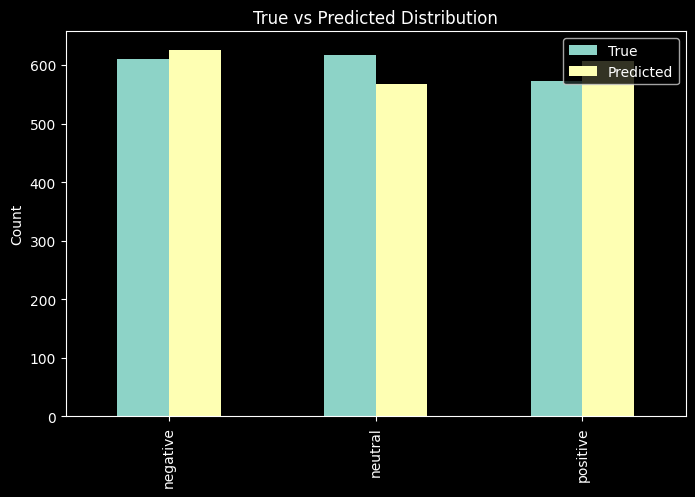

In [45]:
true_counts = pd.Series(sentiment_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
})

df.plot(kind="bar", figsize=(8,5))
plt.title("True vs Predicted Distribution")
plt.ylabel("Count")
plt.show()

In [46]:
for text, true, pred in zip(text_test, sentiment_test, y_pred):
    if true != pred:
        print("TEXT:", text)
        print("TRUE:", true, "PRED:", pred)
        print()

TEXT: #6มีนาคม #เขตบางนา #ก้าวสู่ปีที่28 🎉  สำนักงานเขตบางนา จัดพิธีทำบุญเนื่องในโอกาสวันสถาปนาสำนักงานเขตบางนา ครบรอบปีที่ 27 ก้าวสู่ปีที่ 28 โดยในเวลา 08.19 น. นางประภัสสร จำนงบุตร ผู้อำนวยการเขตบางนา นำคณะผู้บริหารเขต คณะผู้บริหารสถานศึกษาในสังกัดสำนักงานเขต สัสดีเขตบางนา ข้าราชการและบุคลากรสำนักงานเขต ร่วมสักการะพระพุทธพิชิตมาร ศาลพระภูมิเจ้าที่ และศาลตายาย สิ่งศักดิ์สิทธิ์ประจำเขตบางนา บริเวณหน้าอาคารสำนักงานเขตบางนา  เพื่อความร่มเย็น เป็นสุข และเป็นสิริมงคล  🤍🙏 #วันสถาปนาสำนักงานเขตบางนา #กรุงเทพมหานคร #กทม #บางนา #สำนักงานเขตบางนา
TRUE: positive PRED: neutral

TEXT: ไฟไหม้ มีภัย โทร.199 เรียกนักดับเพลิงและกู้ภัย สปภ.กทม.  นักดับเพลิงและกู้ภัยสุทธิสาร กปก.1  1. รับแจ้งจับงูเขียวพระอินทร์ ไม่พบตัวงูดังกล่าว ประชาสัมพันธ์เรียบร้อย ที่เกิดเหตุแฟลต กทม. แฟลต 9 ชั้น 3 ห้อง 500 แขวงรัชดาภิเษก เขตดินแดง กทม. 2....
TRUE: negative PRED: neutral

TEXT: รัฐบาล 'เศรษฐา' ลุยรีดภาษีที่ดิน 100% กทม.ชง 'ชัชชาติ' รื้ออัตราใหม่ ดัดหลังเศรษฐี-เกษตรกรจำแลง | มติชนสุดสัปดาห์ | LINE TODAY
TRUE: positi

In [47]:

with open("../../models/weights/stack_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)